# Javier Prado × Salaverry: cinco cámaras virtuales

Este cuaderno permite revisar el mapa, las señales semafóricas observadas y el
primer experimento de aprendizaje de tiempos. **La demanda, las emergencias y los
bloqueos son sintéticos.** Las cámaras son sensores ideales por carriles: el visor
muestra una vista cenital del simulador, sin generar ni analizar video de cámaras.

Selecciona el intérprete `.venv/bin/python`. La instalación y los comandos están
en [README.md](README.md). Ejecutar este cuaderno sólo lee los resultados existentes.


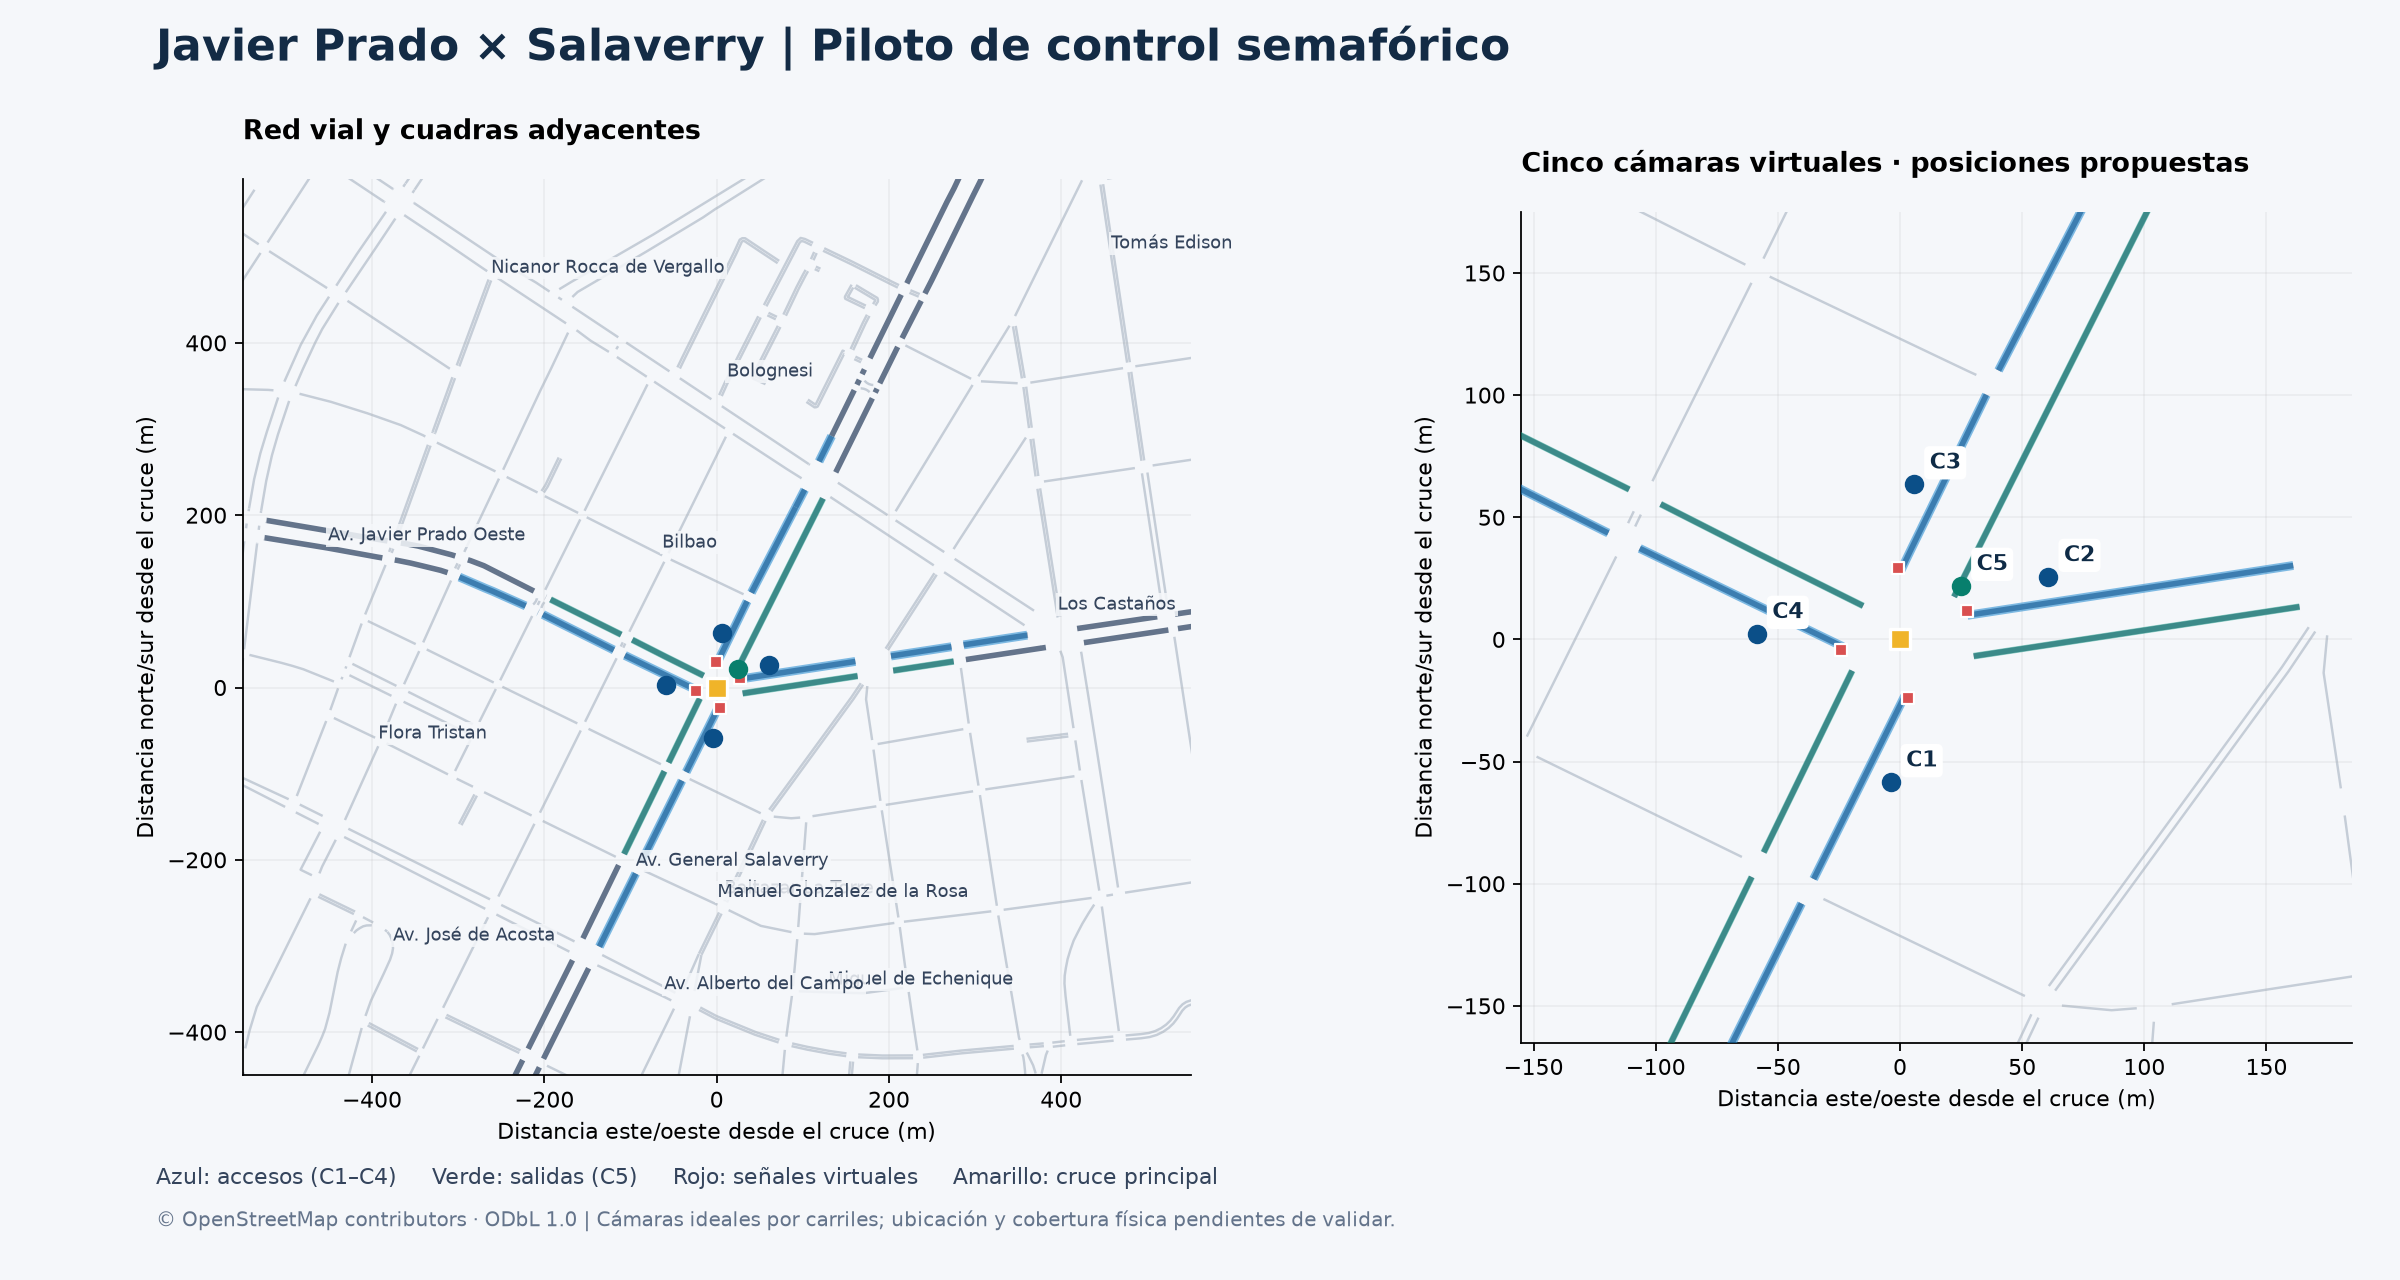

In [1]:
from pathlib import Path
import json
from IPython.display import display, Image, HTML

ROOT = Path.cwd()
if not (ROOT / "data" / "pilot.net.xml").exists():
    raise RuntimeError("Abre el cuaderno desde la carpeta del proyecto.")
display(Image(filename=str(ROOT / "outputs" / "mapa_camaras.png")))


## Cobertura y semáforos

C1–C4 cubren los cuatro accesos y las señales que gobiernan sus movimientos.
C5 observa las calles receptoras. La cobertura por carriles es ideal y aún no
representa perspectiva ni oclusiones. La posición de cinco cámaras físicas debe
validarse: una sola cámara en C5 podría no observar todas las salidas.

El cruce usa fases exclusivas por acceso, generadas por SUMO. Los giros usan las
conexiones inferidas del mapa; no se confirma la existencia de carriles exclusivos
de giro ni que estas fases coincidan con el programa real de la municipalidad.


In [2]:
inventory = json.loads((ROOT / "data" / "cameras.json").read_text())
rows = "".join(f"<tr><td>{c['id']}</td><td>{c['label']}</td><td>{len(c['coverage_lanes'])}</td><td>{len(c['visible_signal_links'])}</td></tr>" for c in inventory['cameras'])
display(HTML("<table><tr><th>Cámara</th><th>Acceso/cobertura</th><th>Carriles observados</th><th>Señales lógicas visibles</th></tr>" + rows + "</table>"))


Cámara,Acceso/cobertura,Carriles observados,Señales lógicas visibles
C1,Salaverry · sur,6,5
C2,Javier Prado · este,6,5
C3,Salaverry · norte,8,5
C4,Javier Prado · oeste,8,6
C5,Salidas y área del cruce,16,21


## Recorrer la simulación

Mueve el control de tiempo para inspeccionar las colas, los giros y los colores
observados de los semáforos. Las emergencias activas se muestran en naranja y
violeta; el patrullero inactivo se comporta como tráfico normal. Los vehículos
dibujados son información de la simulación; el controlador sólo recibe las
observaciones filtradas por la cobertura de las cinco cámaras.


In [3]:
import io
import matplotlib.pyplot as plt
from pilot.network import Layout
from pilot.visuals import snapshot_figure

layout = Layout()
trace = json.loads((ROOT / "outputs" / "demo" / "trace.json").read_text())

def show_frame(second):
    row = trace[min(max(int(second) - 1, 0), len(trace) - 1)]
    figure = snapshot_figure(layout, row)
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=115)
    plt.close(figure)
    display(Image(data=buffer.getvalue()))

default_second = next((r['time_s'] for r in trace if any(r['blocked'])), 180)
try:
    import ipywidgets as widgets
    viewer = widgets.interactive(show_frame, second=widgets.IntSlider(
        value=default_second, min=1, max=len(trace), step=1, description="Tiempo (s)",
        continuous_update=False, layout=widgets.Layout(width="95%")))
    display(viewer)
except ImportError:
    show_frame(default_second)


interactive(children=(IntSlider(value=281, continuous_update=False, description='Tiempo (s)', layout=Layout(wi…

## Demostración y verificaciones

Se simulan diez minutos con giros, aumento temporal de demanda, una salida
obstruida, emergencias activas y un patrullero inactivo. Los tiempos de parada
incluyen las calles vecinas, cuyos semáforos todavía siguen planes sintéticos.
El final del episodio puede dejar vehículos sin completar su recorrido.


Entraron 365 vehículos; completaron recorrido 307.
Quedan en la red: 58; pendientes de entrar: 0.
Cola media visible: 37.06 vehículos.
Colisiones: 0; retiros artificiales: 0.
Muestras de un segundo con congestión de salida: 42.
Límites de verde y transiciones: passed passed


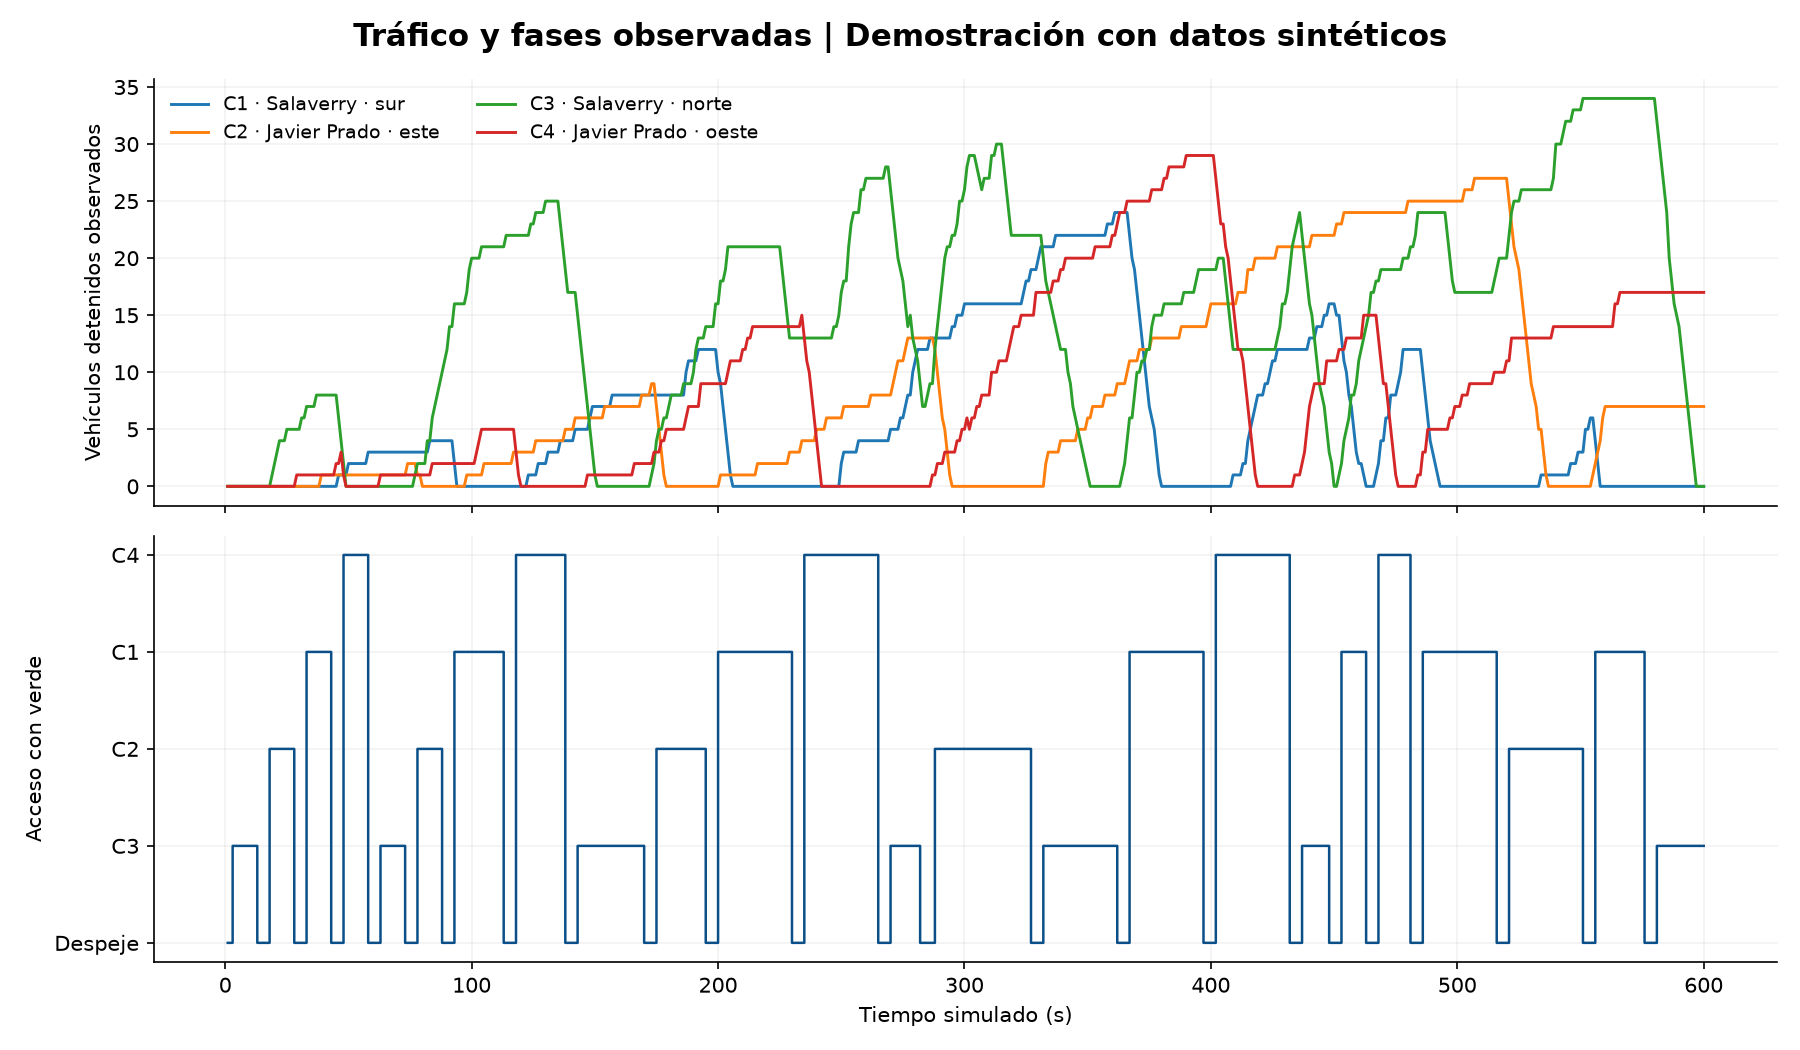

In [4]:
metrics = json.loads((ROOT / "outputs" / "demo" / "metrics.json").read_text())
verification = json.loads((ROOT / "outputs" / "verification.json").read_text())
print(f"Entraron {metrics['departed']} vehículos; completaron recorrido {metrics['arrived']}.")
print(f"Quedan en la red: {metrics['still_in_network']}; pendientes de entrar: {metrics['pending_departures']}.")
print(f"Cola media visible: {metrics['observed_mean_queue_vehicles']:.2f} vehículos.")
print(f"Colisiones: {metrics['colliding_vehicle_count']}; retiros artificiales: {metrics['teleports']}.")
print(f"Muestras de un segundo con congestión de salida: {verification['blocked_samples']}.")
print("Límites de verde y transiciones:", verification['green_limits'], verification['allowed_phases_and_transitions'])
display(Image(filename=str(ROOT / "outputs" / "demo" / "trafico.png")))


## Aprendizaje y comparación

El modelo aprende a elegir **10, 20 o 30 segundos de verde**. El acceso a servir se
elige mediante reglas de demanda, prioridad de emergencia y congestión. La
recompensa penaliza colas y detención de emergencias. Es un controlador híbrido:
el aprendizaje asigna duración y las reglas restringen las acciones.

Los tres controladores comparados comparten las mismas reglas de prioridad,
amarillo, despeje y bloqueo. `fixed` usa siempre 20 segundos; `adaptive` elige la
duración según la cola; `qlearning` usa la tabla aprendida. Las semillas de
evaluación son diferentes a las de entrenamiento. Este entrenamiento breve
comprueba el funcionamiento del sistema y no demuestra mejora en tráfico real.


In [5]:
from statistics import mean

training = json.loads((ROOT / "outputs" / "training.json").read_text())
model = json.loads((ROOT / "outputs" / "model.json").read_text())
evaluation = json.loads((ROOT / "outputs" / "evaluation.json").read_text())
print(f"Entrenamiento: {len(training['training_seeds'])} escenarios, {model['updates']} actualizaciones, {len(model['q'])} estados.")
rows = []
for controller in ("fixed", "adaptive", "qlearning"):
    results = [r for r in evaluation['results'] if r['controller'] == controller]
    emergency_waits = [e['stopped_s'] for r in results for e in r['emergencies']]
    rows.append(f"<tr><td>{controller}</td><td>{mean(r['observed_mean_queue_vehicles'] for r in results):.2f}</td><td>{mean(r['arrived'] for r in results):.1f}</td><td>{mean(emergency_waits):.1f}</td><td>{sum(r['colliding_vehicle_count'] for r in results)}</td></tr>")
display(HTML("<table><tr><th>Controlador</th><th>Cola media (veh.)</th><th>Llegadas medias</th><th>Parada media de emergencia (s)</th><th>Vehículos con colisión</th></tr>" + "".join(rows) + "</table>"))
print("Se informan esperas parciales si una emergencia no terminó su recorrido dentro del horizonte.")


Entrenamiento: 25 escenarios, 1043 actualizaciones, 60 estados.


Controlador,Cola media (veh.),Llegadas medias,Parada media de emergencia (s),Vehículos con colisión
fixed,49.17,309.7,19.3,0
adaptive,47.75,314.7,20.5,0
qlearning,56.85,292.0,27.0,0


Se informan esperas parciales si una emergencia no terminó su recorrido dentro del horizonte.


## Repetir o ampliar el experimento

Desde la carpeta del proyecto:

```bash
.venv/bin/python -m pilot.cli demo --seconds 600
.venv/bin/python -m pilot.cli experiment --episodes 25 --seconds 600 --seed 7 --seeds 101,102,103
.venv/bin/python -m unittest discover -s tests -v
```

Para avanzar hacia cámaras reales: revisar geometría, giros y fases en campo;
medir llegadas y proporciones de giro; incorporar peatones, ciclistas y transporte
público; modelar cobertura y errores de detección; validar la confirmación de
emergencias activas. El control visual de señales sólo observa su estado: un
sistema físico requiere también conexión autorizada al controlador semafórico.

Mapa: [© OpenStreetMap contributors, ODbL 1.0](https://www.openstreetmap.org/copyright).
Las restricciones y supuestos completos están en [README.md](README.md).
